### Time Series Forecasting

Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings. filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import holidays

Load data

In [2]:
df = pd.read_csv('C:\PlantNxt Assignment\data\processed\data.csv')
df.head()

,Account,Cust Code,Part Code,Inv Date,Quantity,Price,Tax,Others
0,Account A,Cust-00762,Part-01473,2022-04-01,3.0,9787.10,8415.52,694.14
1,Account A,Cust-00762,Part-01473,2022-04-01,10.0,9787.10,28051.74,2313.80
2,Account A,Cust-00519,Part-01675,2022-04-01,18.6,46045.00,154158.66,10105.96
3,Account A,Cust-00302,Part-01312,2022-04-01,5.0,4761.14,4570.44,1585.65
4,Account A,Cust-00302,Part-01573,2022-04-01,5.0,4752.34,4562.52,1585.65


In [3]:
df.columns = df.columns.str.strip()
df['Inv Date'] = pd.to_datetime(df['Inv Date'])
df['Revenue'] = df['Quantity'] * df['Price']

Aggregation

In [4]:
daily_df = (
    df.groupby('Inv Date')
    .agg({
        'Revenue': 'sum',
        'Quantity': 'sum',
        'Part Code': 'nunique',
    }))

Feature Engineering

In [ ]:
def build_features(d):

    # calender features
    d['dayofweek'] = d.index.dayofweek
    d['month'] = d.index.month
    d['quarter'] = d.index.quarter
    d['is_month_start'] = d.index.is_month_start.astype(int)
    d['is_month_end'] = d.index.is_month_end.astype(int)
    d['is_weekend'] = (d.index.dayofweek >= 5).astype(int)


    # lag features
    for lag in [1, 7, 30]:
        d[f'lag_{lag}'] = d['Revenue'].shift(lag)

    # rolling window statitics
    for window in [7, 14, 30]:
        d[f'roll_mean_{window}'] = d['Revenue'].rolling(window).mean()
        d[f'roll_std_{window}'] = d['Revenue'].rolling(window).std()
    
    # holidays
    india_holidays = holidays.India()

    d['is_holiday'] = (
        d.index.to_series().apply(lambda x: 1 if x in india_holidays else 0)
    )

    return d

daily_df = build_features(daily_df)

#drop rows with NaN from lag/rolling 
daily_df.dropna(inplace = True)


Train-Test Split

In [6]:
target = 'Revenue'

feature_cols = daily_df.drop(columns = [target])

X = feature_cols
y = daily_df[target]

test_days = 30

X_train = X.iloc[:-test_days]
X_test = X.iloc[-test_days:]

y_train = y.iloc[:-test_days]
y_test = y.iloc[-test_days:]

Normalization

In [7]:
# Scale target with log1p transform (stabilizes variance across regime)
y_train_log = np.log1p(y_train)

XGBoost Model

In [8]:
model = XGBRegressor(
    n_estimators = 500,
    learning_rate = 0.03,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state      = 42
)

model.fit(X_train, y_train_log)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Prediction

In [9]:
pred_log = model.predict(X_test)
pred     = np.expm1(pred_log)

Evaluation 

In [10]:
def calculate_metrics(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mask = actual != 0
    mape = mean_absolute_percentage_error(actual, predicted)
    return mae, rmse, mape

mae, rmse, mape = calculate_metrics(y_test, pred)

print('Evaluation Results')
print("-----------------------")
print(f"MAE: {mae:>15,.0f}")
print(f'RMSE: {rmse:>15,.0f}')
print(f"MAPE: {mape:>14.2f}%")
print('-----------------------')

Evaluation Results
-----------------------
MAE:       3,247,705
RMSE:       4,718,697
MAPE:           0.18%
-----------------------


Plots

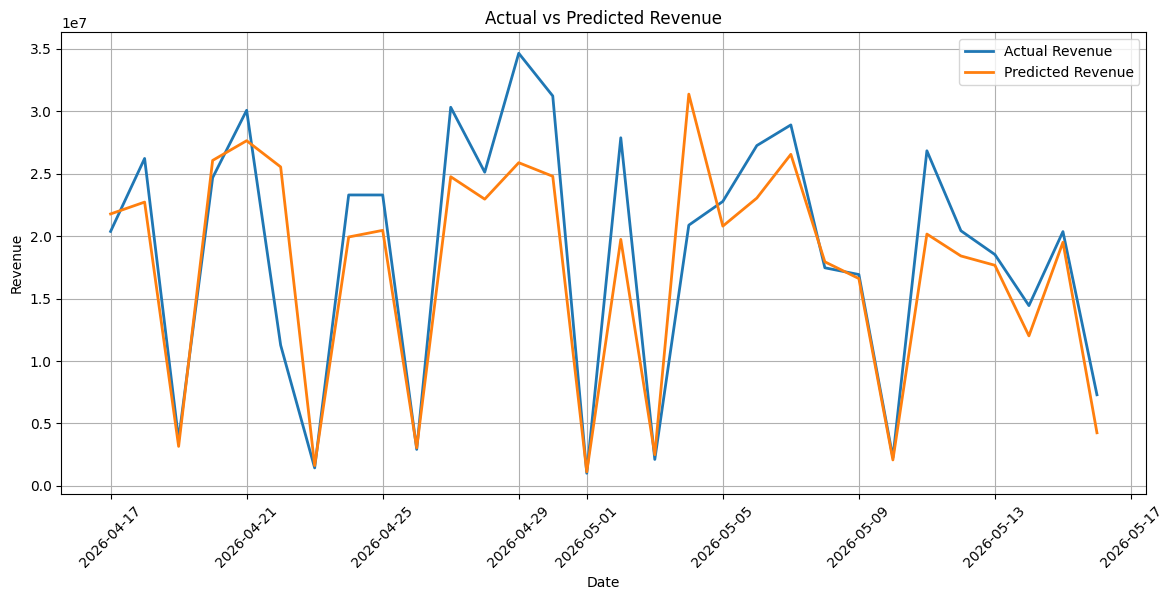

In [ ]:
plt.figure(figsize = (14, 6))

plt.plot(y_test.index, y_test.values, label = 'Actual Revenue', linewidth = 2)
plt.plot( y_test.index, pred, label = 'Predicted Revenue', linewidth = 2)

plt.title('Actual vs Predicted Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation = 45)
plt.legend()
plt.grid(True)
plt.show()